# CLASSIFICATION

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from lightgbm import LGBMClassifier
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [3]:
df = pd.read_csv("clean_data.csv")

df.head()

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


## Features and Target

In [4]:
X = df.drop(["completion_status"],axis=1)

y = df["completion_status"]

## Train Test Split

In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

## Decision Tree Classifier

In [6]:
dt = DecisionTreeClassifier(random_state=42)
start = time.time()

dt.fit(X_train,y_train)

dt_time = time.time()-start
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

## Evaluation

In [7]:
dt_accuracy = accuracy_score(y_test,dt_pred)
dt_precision = precision_score(y_test,dt_pred)
dt_recall = recall_score(y_test,dt_pred)
dt_f1 = f1_score(y_test,dt_pred)
dt_auc = roc_auc_score(y_test,dt_prob)

print("Decision Tree Accuracy:",dt_accuracy)
print("Precision:",dt_precision)
print("Recall:",dt_recall)
print("F1:",dt_f1)
print("ROC AUC:",dt_auc)

Decision Tree Accuracy: 0.7682692307692308
Precision: 0.6792452830188679
Recall: 0.732824427480916
F1: 0.7050183598531212
ROC AUC: 0.7613117500619417


## LightGB Classifier

In [8]:
lgbm = LGBMClassifier(

    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

start = time.time()

lgbm.fit(X_train,y_train)

lgbm_time = time.time()-start
lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 1559, number of negative: 2601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1250
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.374760 -> initscore=-0.511851
[LightGBM] [Info] Start training from score -0.511851
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

## Evaluation

In [9]:
lgbm_accuracy = accuracy_score(y_test,lgbm_pred)
lgbm_precision = precision_score(y_test,lgbm_pred)
lgbm_recall = recall_score(y_test,lgbm_pred)
lgbm_f1 = f1_score(y_test,lgbm_pred)
lgbm_auc = roc_auc_score(y_test,lgbm_prob)

print("Accuracy :",lgbm_accuracy)
print("Precision :",lgbm_precision)
print("Recall :",lgbm_recall)
print("F1 :",lgbm_f1)
print("ROC AUC :",lgbm_auc)

Accuracy : 0.8259615384615384
Precision : 0.7819148936170213
Recall : 0.7480916030534351
F1 : 0.764629388816645
ROC AUC : 0.8988559450350216


## Confusion Matrix

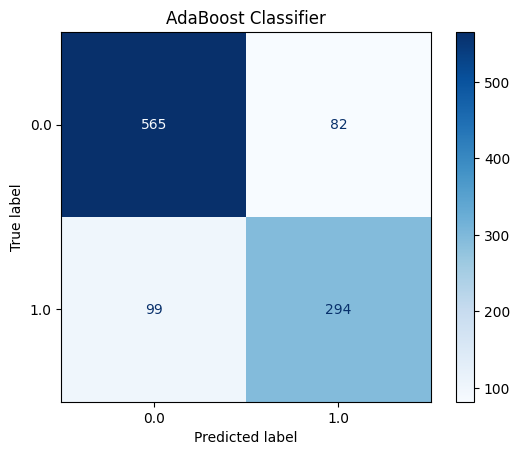

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lgbm_pred,
    cmap="Blues"
)

plt.title("AdaBoost Classifier")
plt.show()

## ROC Curve

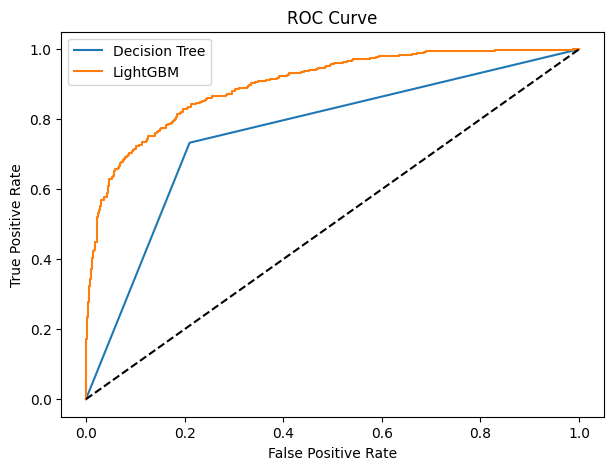

In [11]:
dt_fpr,dt_tpr,_ = roc_curve(y_test,dt_prob)
lgbm_fpr,lgbm_tpr,_ = roc_curve(y_test,lgbm_prob)

plt.figure(figsize=(7,5))
plt.plot(dt_fpr,dt_tpr,label="Decision Tree")

plt.plot(lgbm_fpr,lgbm_tpr,label="LightGBM")
plt.plot([0,1],[0,1],"k--")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Classification Comparison

In [12]:
classification_results=pd.DataFrame({
"Model":["Decision Tree","LightGB"],
"Accuracy":[dt_accuracy,lgbm_accuracy],
"Precision":[dt_precision,lgbm_precision],
"Recall":[dt_recall,lgbm_recall],
"F1 Score":[dt_f1,lgbm_f1],
"ROC AUC":[dt_auc,lgbm_auc]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.768269,0.679245,0.732824,0.705018,0.761312
1,LightGB,0.825962,0.781915,0.748092,0.764629,0.898856


## Training Time Comparison

In [20]:
classification_time = pd.DataFrame({

    "Model":["Decision Tree","LightGBM"],
    "Training Time (sec)":[dt_time,lgbm_time]

})

classification_time

,Model,Training Time (sec)
0,Decision Tree,0.413346
1,LightGBM,30.317366


# REGRESSION

## Features and Target

In [13]:
X=df.drop(["final_score"],axis=1)

y=df["final_score"]

## Train Test Split

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

## Decision Tree Regressor

In [15]:
dtr = DecisionTreeRegressor(random_state=42)
start = time.time()

dtr.fit(X_train,y_train)
dt_time_reg = time.time()-start
dt_pred = dtr.predict(X_test)

## Evaluation

In [16]:
dt_mae=mean_absolute_error(y_test,dt_pred)
dt_rmse=np.sqrt(mean_squared_error(y_test,dt_pred))
dt_r2=r2_score(y_test,dt_pred)

print("MAE:",dt_mae)
print("RMSE:",dt_rmse)
print("R2:",dt_r2)

MAE: 9.234615384615385
RMSE: 11.773122094251542
R2: 0.2581528173374218


## LightGBM Regressor

In [19]:
lgbm_reg = LGBMRegressor(

    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

start = time.time()

lgbm_reg.fit(X_train,y_train)
lgbm_time_reg = time.time()-start
lgbm_pred = lgbm_reg.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1001
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 16
[LightGBM] [Info] Start training from score 74.774183
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## Evaluation

In [18]:
lgbm_mae = mean_absolute_error(y_test,lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test,lgbm_pred))
lgbm_r2 = r2_score(y_test,lgbm_pred)

print("MAE :",lgbm_mae)
print("RMSE :",lgbm_rmse)
print("R2 :",lgbm_r2)

MAE : 6.78287264172747
RMSE : 8.456842646567607
R2 : 0.6172213947552987


In [ ]:
regression_time = pd.DataFrame({

    "Model":["Decision Tree","LightGBM"],
    "Training Time (sec)":[dt_time_reg,lgbm_time_reg]

})

regression_time

,Model,Training Time (sec)
0,Decision Tree,0.176884
1,LightGBM,0.375153


## Regression Comparison

In [21]:
regression_results = pd.DataFrame({

    "Model":["Decision Tree","LightGBM"],
    "MAE":[dt_mae,lgbm_mae],
    "RMSE":[dt_rmse,lgbm_rmse],
    "R2 Score":[dt_r2,lgbm_r2]

})

regression_results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,9.234615,11.773122,0.258153
1,LightGBM,6.782873,8.456843,0.617221


## Final Comparison

In [ ]:
print("Classification Results")
print(classification_results)

print()

print("Regression Results")
print(regression_results)
print()

print("Training Time Comparison")

print(classification_time)
print(regression_time)

Classification Results
           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Decision Tree  0.768269   0.679245  0.732824  0.705018  0.761312
1        LightGB  0.825962   0.781915  0.748092  0.764629  0.898856

Regression Results
           Model       MAE       RMSE  R2 Score
0  Decision Tree  9.234615  11.773122  0.258153
1       LightGBM  6.782873   8.456843  0.617221

Training Time Comparison
           Model  Training Time (sec)
0  Decision Tree             0.413346
1       LightGBM            30.317366
           Model  Training Time (sec)
0  Decision Tree             0.176884
1       LightGBM             0.375153


# Conclusion

## Performance Analysis

* LightGBM generally provides higher Accuracy, Precision, Recall, F1-Score, and ROC-AUC than a single Decision Tree by building an optimized ensemble of trees.
* For regression, it usually achieves lower MAE and RMSE and a higher R² score, resulting in more accurate predictions.

## Training Efficiency Analysis

* LightGBM uses histogram-based learning and leaf-wise tree growth, making it highly efficient on medium and large datasets.
* It typically trains faster than many traditional boosting methods while maintaining strong predictive performance.